# 07. Recommendation Prototype

This notebook builds and evaluates a lightweight item-to-item recommendation prototype from historical user interaction sequences. Because the Retailrocket data contain no product names, descriptions, prices, or item-category mapping, recommendations are based on behavioral co-occurrence rather than product content.

In [1]:
# Purpose: Load cleaned Retailrocket interactions and prepare them for behavior-based recommendation modeling.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"

cleaned_events_path = processed_data_dir / "events_cleaned.csv"

recommendation_events_df = pd.read_csv(cleaned_events_path)

recommendation_events_df["event_datetime"] = pd.to_datetime(
    recommendation_events_df["timestamp"],
    unit="ms"
)

recommendation_events_df = recommendation_events_df.sort_values(
    ["visitorid", "event_datetime"]
).reset_index(drop=True)

print(f"Project root: {project_root}")
print(f"Cleaned interaction dataset shape: {recommendation_events_df.shape}")
print(
    "Observation period: "
    f"{recommendation_events_df['event_datetime'].min()} to "
    f"{recommendation_events_df['event_datetime'].max()}"
)

display(recommendation_events_df.head())

Project root: F:\ecommerce-recommender-xai
Cleaned interaction dataset shape: (2755641, 6)
Observation period: 2015-05-03 03:00:04.384000 to 2015-09-18 02:59:47.788000


,timestamp,visitorid,event,itemid,transactionid,event_datetime
0,1442004589439,0,view,285930,NaN,2015-09-11 20:49:49.439
1,1442004759591,0,view,357564,NaN,2015-09-11 20:52:39.591
2,1442004917175,0,view,67045,NaN,2015-09-11 20:55:17.175
3,1439487966444,1,view,72028,NaN,2015-08-13 17:46:06.444
4,1438969904567,2,view,325215,NaN,2015-08-07 17:51:44.567


In [2]:
# Purpose: Create 30-minute inactivity-based behavioral sessions from chronologically ordered user interactions.

SESSION_GAP_MINUTES = 30

recommendation_events_df["previous_event_time"] = (
    recommendation_events_df
    .groupby("visitorid")["event_datetime"]
    .shift()
)

recommendation_events_df["minutes_since_previous_event"] = (
    recommendation_events_df["event_datetime"]
    - recommendation_events_df["previous_event_time"]
).dt.total_seconds() / 60

recommendation_events_df["starts_new_session"] = (
    recommendation_events_df["minutes_since_previous_event"].isna()
    | (
        recommendation_events_df["minutes_since_previous_event"]
        > SESSION_GAP_MINUTES
    )
)

recommendation_events_df["behavior_session_id"] = (
    recommendation_events_df["starts_new_session"]
    .cumsum()
    .astype("int32")
)

session_summary = (
    recommendation_events_df
    .groupby("behavior_session_id")
    .agg(
        visitorid=("visitorid", "first"),
        session_start=("event_datetime", "min"),
        session_end=("event_datetime", "max"),
        event_count=("event", "size"),
        unique_item_count=("itemid", "nunique")
    )
)

session_summary["session_duration_minutes"] = (
    session_summary["session_end"] - session_summary["session_start"]
).dt.total_seconds() / 60

print(f"Number of behavioral sessions: {len(session_summary):,}")
print(f"Median events per session: {session_summary['event_count'].median():.0f}")
print(f"Median unique items per session: {session_summary['unique_item_count'].median():.0f}")
print(
    "Sessions containing more than one unique item: "
    f"{(session_summary['unique_item_count'] > 1).mean():.2%}"
)

display(session_summary.head())

Number of behavioral sessions: 1,761,675
Median events per session: 1
Median unique items per session: 1
Sessions containing more than one unique item: 14.98%


,visitorid,session_start,session_end,event_count,unique_item_count,session_duration_minutes
behavior_session_id,,,,,,
1,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,3,3,5.462267
2,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,1,1,0.000000
3,2,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,8,4,29.221300
4,3,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,1,1,0.000000
5,4,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,1,1,0.000000


In [3]:
# Purpose: Select multi-item behavioral sessions suitable for efficient item-to-item co-occurrence modeling.

MAX_ITEMS_PER_SESSION = 20

eligible_session_summary = session_summary.loc[
    (session_summary["unique_item_count"] >= 2)
    & (session_summary["unique_item_count"] <= MAX_ITEMS_PER_SESSION)
].copy()

excluded_large_sessions = session_summary.loc[
    session_summary["unique_item_count"] > MAX_ITEMS_PER_SESSION
]

session_selection_summary = pd.DataFrame({
    "metric": [
        "All behavioral sessions",
        "Sessions with at least two unique items",
        "Eligible sessions with 2 to 20 unique items",
        "Excluded sessions with more than 20 unique items",
        "Unique items in eligible sessions"
    ],
    "value": [
        len(session_summary),
        int((session_summary["unique_item_count"] >= 2).sum()),
        len(eligible_session_summary),
        len(excluded_large_sessions),
        recommendation_events_df.loc[
            recommendation_events_df["behavior_session_id"].isin(
                eligible_session_summary.index
            ),
            "itemid"
        ].nunique()
    ]
})

display(session_selection_summary)

eligible_session_items = (
    recommendation_events_df.loc[
        recommendation_events_df["behavior_session_id"].isin(
            eligible_session_summary.index
        ),
        ["behavior_session_id", "itemid"]
    ]
    .drop_duplicates()
    .sort_values(["behavior_session_id", "itemid"])
)

print(
    "\nUnique session-item records available for co-occurrence modeling: "
    f"{len(eligible_session_items):,}"
)

display(eligible_session_items.head())

,metric,value
0,All behavioral sessions,1761675
1,Sessions with at least two unique items,263899
2,Eligible sessions with 2 to 20 unique items,262165
3,Excluded sessions with more than 20 unique items,1734
4,Unique items in eligible sessions,116853



Unique session-item records available for co-occurrence modeling: 782,117


,behavior_session_id,itemid
2,1,67045
0,1,285930
1,1,357564
7,3,216305
6,3,259884


In [4]:
# Purpose: Count item pairs that co-occur within eligible behavioral sessions for item-to-item recommendations.

from collections import Counter
from itertools import combinations

session_item_lists = (
    eligible_session_items
    .groupby("behavior_session_id")["itemid"]
    .agg(list)
)

item_session_frequency = (
    eligible_session_items["itemid"]
    .value_counts()
    .rename("item_session_count")
)

pair_counter = Counter()

for session_number, item_list in enumerate(session_item_lists, start=1):
    pair_counter.update(combinations(item_list, 2))

    if session_number % 50_000 == 0:
        print(
            f"Processed {session_number:,} eligible sessions; "
            f"unique item pairs found: {len(pair_counter):,}"
        )

MIN_PAIR_CO_OCCURRENCES = 2

cooccurrence_pairs_df = pd.DataFrame(
    [
        {
            "item_id_a": item_a,
            "item_id_b": item_b,
            "cooccurrence_count": pair_count
        }
        for (item_a, item_b), pair_count in pair_counter.items()
        if pair_count >= MIN_PAIR_CO_OCCURRENCES
    ]
)

print(f"\nAll unique co-occurring item pairs: {len(pair_counter):,}")
print(
    "Pairs retained with at least "
    f"{MIN_PAIR_CO_OCCURRENCES} co-occurrences: "
    f"{len(cooccurrence_pairs_df):,}"
)

display(
    cooccurrence_pairs_df
    .sort_values("cooccurrence_count", ascending=False)
    .head(10)
)

Processed 50,000 eligible sessions; unique item pairs found: 229,039
Processed 100,000 eligible sessions; unique item pairs found: 425,000
Processed 150,000 eligible sessions; unique item pairs found: 601,479
Processed 200,000 eligible sessions; unique item pairs found: 768,169
Processed 250,000 eligible sessions; unique item pairs found: 925,823

All unique co-occurring item pairs: 961,492
Pairs retained with at least 2 co-occurrences: 148,751


,item_id_a,item_id_b,cooccurrence_count
2368,218794,461686,264
2367,171878,461686,213
2423,219512,384302,195
1869,180751,298009,187
1288,257040,309778,176
6123,9877,241555,165
2623,96924,340093,147
2514,84160,370653,140
4129,241555,325310,136
2489,354759,452896,129


In [5]:
# Purpose: Convert raw co-occurrence counts into balanced cosine-association scores and save top item-to-item recommendations.

MIN_RECOMMENDATION_CO_OCCURRENCES = 5
TOP_RECOMMENDATIONS_PER_ITEM = 10

item_frequency_df = (
    item_session_frequency
    .rename_axis("item_id")
    .reset_index()
)

scored_pairs_df = (
    cooccurrence_pairs_df
    .loc[
        cooccurrence_pairs_df["cooccurrence_count"]
        >= MIN_RECOMMENDATION_CO_OCCURRENCES
    ]
    .merge(
        item_frequency_df.rename(
            columns={
                "item_id": "item_id_a",
                "item_session_count": "item_a_session_count"
            }
        ),
        on="item_id_a",
        how="left"
    )
    .merge(
        item_frequency_df.rename(
            columns={
                "item_id": "item_id_b",
                "item_session_count": "item_b_session_count"
            }
        ),
        on="item_id_b",
        how="left"
    )
)

scored_pairs_df["cosine_association_score"] = (
    scored_pairs_df["cooccurrence_count"]
    / np.sqrt(
        scored_pairs_df["item_a_session_count"]
        * scored_pairs_df["item_b_session_count"]
    )
)

directed_recommendations_df = pd.concat(
    [
        scored_pairs_df.rename(
            columns={
                "item_id_a": "source_item_id",
                "item_id_b": "recommended_item_id",
                "item_a_session_count": "source_item_session_count",
                "item_b_session_count": "recommended_item_session_count"
            }
        ),
        scored_pairs_df.rename(
            columns={
                "item_id_b": "source_item_id",
                "item_id_a": "recommended_item_id",
                "item_b_session_count": "source_item_session_count",
                "item_a_session_count": "recommended_item_session_count"
            }
        )
    ],
    ignore_index=True
)

item_to_item_recommendations = (
    directed_recommendations_df
    .sort_values(
        [
            "source_item_id",
            "cosine_association_score",
            "cooccurrence_count"
        ],
        ascending=[True, False, False]
    )
    .groupby("source_item_id", group_keys=False)
    .head(TOP_RECOMMENDATIONS_PER_ITEM)
    .reset_index(drop=True)
)

recommendations_path = (
    processed_data_dir / "retailrocket_item_to_item_recommendations.csv"
)
item_to_item_recommendations.to_csv(recommendations_path, index=False)

print(
    "Source items with at least one reliable recommendation: "
    f"{item_to_item_recommendations['source_item_id'].nunique():,}"
)
print(
    "Total stored directed recommendations: "
    f"{len(item_to_item_recommendations):,}"
)

example_source_item = item_to_item_recommendations[
    "source_item_id"
].value_counts().index[0]

print(f"\nExample recommendations for source item: {example_source_item}")
display(
    item_to_item_recommendations.loc[
        item_to_item_recommendations["source_item_id"] == example_source_item,
        [
            "source_item_id",
            "recommended_item_id",
            "cooccurrence_count",
            "cosine_association_score",
            "source_item_session_count",
            "recommended_item_session_count"
        ]
    ]
)

print(f"\nSaved item-to-item recommendations to: {recommendations_path}")

Source items with at least one reliable recommendation: 12,033
Total stored directed recommendations: 38,282

Example recommendations for source item: 350629


,source_item_id,recommended_item_id,cooccurrence_count,cosine_association_score,source_item_session_count,recommended_item_session_count
28717,350629,397236,24,0.187323,245,67
28718,350629,418200,11,0.140553,245,25
28719,350629,17189,16,0.140410,245,53
28720,350629,335975,36,0.134595,245,292
28721,350629,170811,23,0.127415,245,133
28722,350629,91755,23,0.107168,245,188
28723,350629,333147,12,0.098974,245,60
28724,350629,27283,8,0.091796,245,31
28725,350629,457338,7,0.091287,245,24
28726,350629,238059,7,0.068199,245,43



Saved item-to-item recommendations to: F:\ecommerce-recommender-xai\data\processed\retailrocket_item_to_item_recommendations.csv


In [6]:
# Purpose: Create a chronological train-test split for leakage-safe offline evaluation of the item-to-item recommender.

recommender_time_cutoff = eligible_session_summary["session_start"].quantile(0.80)

recommender_train_session_ids = eligible_session_summary.index[
    eligible_session_summary["session_start"] <= recommender_time_cutoff
]

recommender_test_session_ids = eligible_session_summary.index[
    eligible_session_summary["session_start"] > recommender_time_cutoff
]

test_session_item_sequences = (
    recommendation_events_df.loc[
        recommendation_events_df["behavior_session_id"].isin(
            recommender_test_session_ids
        ),
        ["behavior_session_id", "event_datetime", "itemid"]
    ]
    .sort_values(["behavior_session_id", "event_datetime", "itemid"])
    .drop_duplicates(["behavior_session_id", "itemid"], keep="first")
    .groupby("behavior_session_id")["itemid"]
    .agg(list)
)

recommender_test_queries = test_session_item_sequences.loc[
    test_session_item_sequences.apply(len) >= 2
].reset_index(name="item_sequence")

recommender_test_queries["source_item_id"] = (
    recommender_test_queries["item_sequence"].str[0]
)

recommender_test_queries["relevant_future_items"] = (
    recommender_test_queries["item_sequence"].str[1:]
)

split_summary = pd.DataFrame({
    "metric": [
        "Co-occurrence training cutoff",
        "Training multi-item sessions",
        "Test multi-item sessions",
        "Test recommendation queries",
        "Average number of relevant future items per query"
    ],
    "value": [
        recommender_time_cutoff,
        len(recommender_train_session_ids),
        len(recommender_test_session_ids),
        len(recommender_test_queries),
        recommender_test_queries["relevant_future_items"].apply(len).mean()
    ]
})

display(split_summary)

display(recommender_test_queries.head())

,metric,value
0,Co-occurrence training cutoff,2015-08-17 18:48:42.229200128
1,Training multi-item sessions,209732
2,Test multi-item sessions,52433
3,Test recommendation queries,52433
4,Average number of relevant future items per query,1.9108


,behavior_session_id,item_sequence,source_item_id,relevant_future_items
0,1,"[285930, 357564, 67045]",285930,"[357564, 67045]"
1,8,"[253615, 344723]",253615,[344723]
2,64,"[358388, 198762, 429304, 49967, 279059]",358388,"[198762, 429304, 49967, 279059]"
3,67,"[388096, 283115, 38965, 319680]",388096,"[283115, 38965, 319680]"
4,130,"[58827, 420028]",58827,[420028]


In [7]:
# Purpose: Train a time-respecting item-to-item co-occurrence recommender using only historical sessions.

temporal_train_session_items = (
    eligible_session_items.loc[
        eligible_session_items["behavior_session_id"].isin(
            recommender_train_session_ids
        )
    ]
    .copy()
)

temporal_train_item_frequency = (
    temporal_train_session_items["itemid"]
    .value_counts()
    .rename("item_session_count")
)

temporal_train_item_lists = (
    temporal_train_session_items
    .groupby("behavior_session_id")["itemid"]
    .agg(list)
)

temporal_pair_counter = Counter()

for session_number, item_list in enumerate(temporal_train_item_lists, start=1):
    temporal_pair_counter.update(combinations(item_list, 2))

    if session_number % 50_000 == 0:
        print(
            f"Processed {session_number:,} training sessions; "
            f"unique pairs: {len(temporal_pair_counter):,}"
        )

temporal_pair_rows = [
    {
        "item_id_a": item_a,
        "item_id_b": item_b,
        "cooccurrence_count": pair_count
    }
    for (item_a, item_b), pair_count in temporal_pair_counter.items()
    if pair_count >= MIN_RECOMMENDATION_CO_OCCURRENCES
]

temporal_scored_pairs = pd.DataFrame(temporal_pair_rows)

temporal_item_frequency_df = (
    temporal_train_item_frequency
    .rename_axis("item_id")
    .reset_index()
)

temporal_scored_pairs = (
    temporal_scored_pairs
    .merge(
        temporal_item_frequency_df.rename(
            columns={
                "item_id": "item_id_a",
                "item_session_count": "item_a_session_count"
            }
        ),
        on="item_id_a",
        how="left"
    )
    .merge(
        temporal_item_frequency_df.rename(
            columns={
                "item_id": "item_id_b",
                "item_session_count": "item_b_session_count"
            }
        ),
        on="item_id_b",
        how="left"
    )
)

temporal_scored_pairs["cosine_association_score"] = (
    temporal_scored_pairs["cooccurrence_count"]
    / np.sqrt(
        temporal_scored_pairs["item_a_session_count"]
        * temporal_scored_pairs["item_b_session_count"]
    )
)

temporal_directed_recommendations = pd.concat(
    [
        temporal_scored_pairs.rename(
            columns={
                "item_id_a": "source_item_id",
                "item_id_b": "recommended_item_id"
            }
        ),
        temporal_scored_pairs.rename(
            columns={
                "item_id_b": "source_item_id",
                "item_id_a": "recommended_item_id"
            }
        )
    ],
    ignore_index=True
)

temporal_top_recommendations = (
    temporal_directed_recommendations
    .sort_values(
        [
            "source_item_id",
            "cosine_association_score",
            "cooccurrence_count"
        ],
        ascending=[True, False, False]
    )
    .groupby("source_item_id", group_keys=False)
    .head(TOP_RECOMMENDATIONS_PER_ITEM)
)

temporal_recommendation_lookup = (
    temporal_top_recommendations
    .groupby("source_item_id")["recommended_item_id"]
    .agg(list)
    .to_dict()
)

popular_item_baseline = (
    temporal_train_item_frequency
    .head(TOP_RECOMMENDATIONS_PER_ITEM)
    .index
    .tolist()
)

print(f"\nHistorical item-to-item recommendation sources: {len(temporal_recommendation_lookup):,}")
print(f"Top-{TOP_RECOMMENDATIONS_PER_ITEM} popularity baseline: {popular_item_baseline}")

Processed 50,000 training sessions; unique pairs: 225,344
Processed 100,000 training sessions; unique pairs: 418,554
Processed 150,000 training sessions; unique pairs: 598,313
Processed 200,000 training sessions; unique pairs: 764,273

Historical item-to-item recommendation sources: 9,885
Top-10 popularity baseline: [257040, 309778, 219512, 234255, 461686, 384302, 37029, 96924, 9877, 290999]


In [8]:
# Purpose: Evaluate temporal item-to-item recommendations against a popularity baseline using Hit Rate and MRR at 10.

EVALUATION_K = 10

popular_item_candidates = (
    temporal_train_item_frequency
    .head(50)
    .index
    .tolist()
)

def get_popularity_recommendations(source_item_id, k=EVALUATION_K):
    return [
        item_id
        for item_id in popular_item_candidates
        if item_id != source_item_id
    ][:k]

def get_cooccurrence_recommendations(source_item_id, k=EVALUATION_K):
    return temporal_recommendation_lookup.get(source_item_id, [])[:k]

def get_hybrid_recommendations(source_item_id, k=EVALUATION_K):
    cooccurrence_recommendations = get_cooccurrence_recommendations(
        source_item_id,
        k=k
    )

    fallback_recommendations = [
        item_id
        for item_id in get_popularity_recommendations(source_item_id, k=50)
        if item_id not in cooccurrence_recommendations
    ]

    return (cooccurrence_recommendations + fallback_recommendations)[:k]

def evaluate_recommendation_method(
    query_dataframe,
    recommendation_function,
    method_name,
    k=EVALUATION_K
):
    hit_count = 0
    reciprocal_rank_sum = 0
    covered_query_count = 0

    for query in query_dataframe.itertuples(index=False):
        recommendations = recommendation_function(query.source_item_id, k)
        relevant_items = set(query.relevant_future_items)

        if len(recommendations) > 0:
            covered_query_count += 1

        matching_ranks = [
            rank
            for rank, recommended_item in enumerate(recommendations, start=1)
            if recommended_item in relevant_items
        ]

        if matching_ranks:
            hit_count += 1
            reciprocal_rank_sum += 1 / min(matching_ranks)

    total_queries = len(query_dataframe)

    return {
        "method": method_name,
        "evaluation_queries": total_queries,
        "recommendation_coverage": covered_query_count / total_queries,
        f"hit_rate_at_{k}": hit_count / total_queries,
        f"mrr_at_{k}": reciprocal_rank_sum / total_queries,
        "hit_count": hit_count
    }

recommender_evaluation_results = [
    evaluate_recommendation_method(
        recommender_test_queries,
        get_popularity_recommendations,
        "Popularity baseline"
    ),
    evaluate_recommendation_method(
        recommender_test_queries,
        get_cooccurrence_recommendations,
        "Item-to-item co-occurrence"
    ),
    evaluate_recommendation_method(
        recommender_test_queries,
        get_hybrid_recommendations,
        "Hybrid co-occurrence with popularity fallback"
    )
]

recommender_evaluation_table = (
    pd.DataFrame(recommender_evaluation_results)
    .round(4)
)

recommender_evaluation_path = (
    tables_dir / "13_recommendation_prototype_evaluation.csv"
)
recommender_evaluation_table.to_csv(
    recommender_evaluation_path,
    index=False
)

display(recommender_evaluation_table)

print(f"Saved recommendation evaluation to: {recommender_evaluation_path}")

,method,evaluation_queries,recommendation_coverage,hit_rate_at_10,mrr_at_10,hit_count
0,Popularity baseline,52433,1.0000,0.0113,0.0025,592
1,Item-to-item co-occurrence,52433,0.3992,0.1492,0.0918,7824
2,Hybrid co-occurrence with popularity fallback,52433,1.0000,0.1526,0.0924,7999


Saved recommendation evaluation to: F:\ecommerce-recommender-xai\outputs\tables\13_recommendation_prototype_evaluation.csv


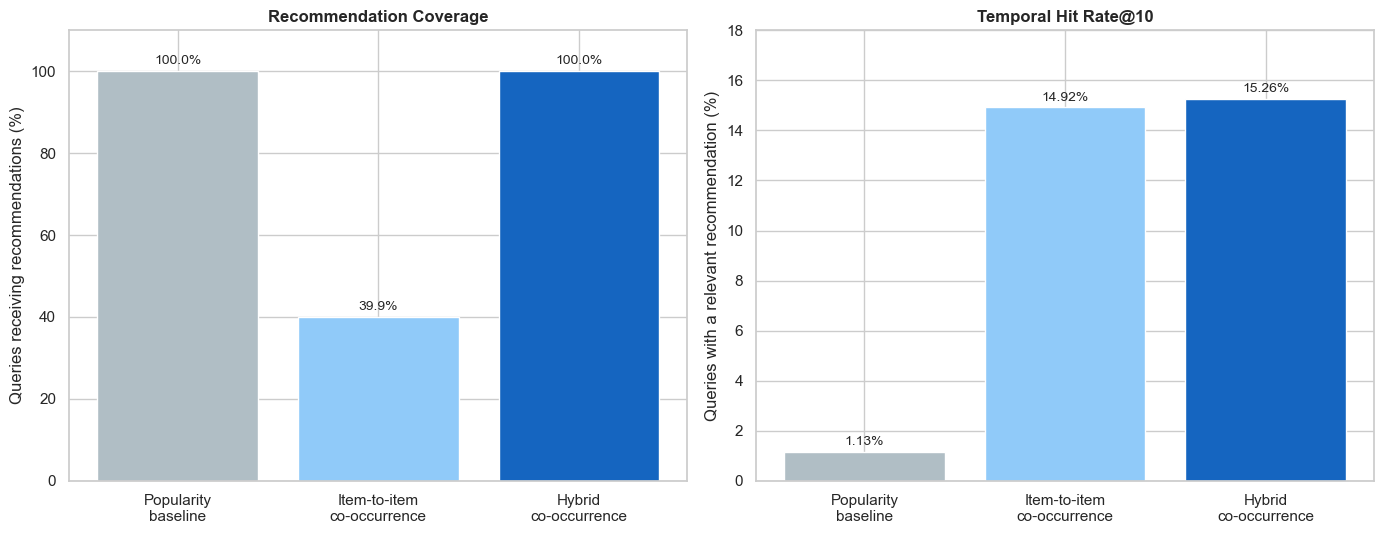

Saved recommendation evaluation figure to: F:\ecommerce-recommender-xai\outputs\figures\16_recommendation_prototype_evaluation.png


In [9]:
# Purpose: Create and save a publication-ready comparison of recommendation coverage and Hit Rate at 10.

recommender_plot_table = recommender_evaluation_table.copy()

recommender_plot_table["conditional_hit_rate_at_10"] = (
    recommender_plot_table["hit_count"]
    / (
        recommender_plot_table["evaluation_queries"]
        * recommender_plot_table["recommendation_coverage"]
    )
)

recommender_plot_table["conditional_hit_rate_at_10"] = (
    recommender_plot_table["conditional_hit_rate_at_10"]
    .fillna(0)
)

method_labels = [
    "Popularity\nbaseline",
    "Item-to-item\nco-occurrence",
    "Hybrid\nco-occurrence"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

coverage_bars = axes[0].bar(
    method_labels,
    recommender_plot_table["recommendation_coverage"] * 100,
    color=["#B0BEC5", "#90CAF9", "#1565C0"]
)

axes[0].set_title("Recommendation Coverage", fontweight="bold")
axes[0].set_ylabel("Queries receiving recommendations (%)")
axes[0].set_ylim(0, 110)

for bar, value in zip(
    coverage_bars,
    recommender_plot_table["recommendation_coverage"] * 100
):
    axes[0].annotate(
        f"{value:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

hit_rate_bars = axes[1].bar(
    method_labels,
    recommender_plot_table["hit_rate_at_10"] * 100,
    color=["#B0BEC5", "#90CAF9", "#1565C0"]
)

axes[1].set_title("Temporal Hit Rate@10", fontweight="bold")
axes[1].set_ylabel("Queries with a relevant recommendation (%)")
axes[1].set_ylim(0, 18)

for bar, value in zip(
    hit_rate_bars,
    recommender_plot_table["hit_rate_at_10"] * 100
):
    axes[1].annotate(
        f"{value:.2f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

recommender_figure_path = (
    figures_dir / "16_recommendation_prototype_evaluation.png"
)
plt.savefig(recommender_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved recommendation evaluation figure to: {recommender_figure_path}")

## Recommendation Prototype Summary

A lightweight item-to-item recommendation prototype was built from items that co-occurred within 30-minute behavioral sessions. The approach uses behavioral association rather than product content because the dataset does not provide product names, descriptions, prices, or an item-to-category mapping.

For leakage-safe evaluation, the recommender was trained only on sessions before 17 August 2015 and evaluated on 52,433 later sessions. Each test query used the first item in a session as the source item and treated later unique item interactions in that session as relevant items.

The hybrid recommender combined item-to-item co-occurrence recommendations with a popularity fallback. It achieved 100% recommendation coverage, Hit Rate@10 of 15.26%, and MRR@10 of 0.0924. This substantially exceeded the popularity baseline, which achieved Hit Rate@10 of 1.13% and MRR@10 of 0.0025.

The prototype demonstrates behavioral recommendation value, but it does not directly predict causal conversion effects or product semantic similarity.

### Saved recommendation outputs

- `retailrocket_item_to_item_recommendations.csv`: item-to-item association recommendations trained on all eligible sessions
- `13_recommendation_prototype_evaluation.csv`: temporal recommendation evaluation results
- `16_recommendation_prototype_evaluation.png`: coverage and Hit Rate@10 comparison figure